# Student Mental Healthcare Data Visualization Exercises

This notebook contains all exercises for visualizing the Student Mental Healthcare dataset.
Each exercise is clearly separated with explanations and code cells.

---

## Setup and Data Cleaning

In [28]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("/Users/sam/Documents/DI_DATA_2025/week9/day2/Student-Mental-Health/Student Mental health.csv")

# Quick look at columns and first rows
print(df.columns)
print(df.head())

# Strip spaces from column names if any
df.columns = df.columns.str.strip()

# Convert relevant columns to clean format and create numeric columns where necessary

# Map CGPA ranges to approximate numeric values (mean of ranges)
cgpa_mapping = {
    '0 - 1.49': 0.75,
    '1.50 - 1.99': 1.75,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df['CGPA_numeric'] = df['What is your CGPA?'].map(cgpa_mapping)

# Convert Anxiety, Depression, Panic attack to numeric 1/0 for easier plotting
for col in ['Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?']:
    df[col + '_num'] = df[col].astype(str).str.strip().str.capitalize().map({'Yes':1, 'No':0})

# Clean Age column: ensure it's numeric and drop invalid
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print("\nData types after cleaning:")
print(df.dtypes)

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')
        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3          

## Exercise 1: Visualizing the Distribution of CGPA

Since CGPA is categorical, we create a histogram-like bar plot of counts by CGPA ranges.
We also use the numeric approx for a true histogram.

---

Two plots:
- Bar plot of counts per CGPA category  
- Histogram of numeric approx CGPA

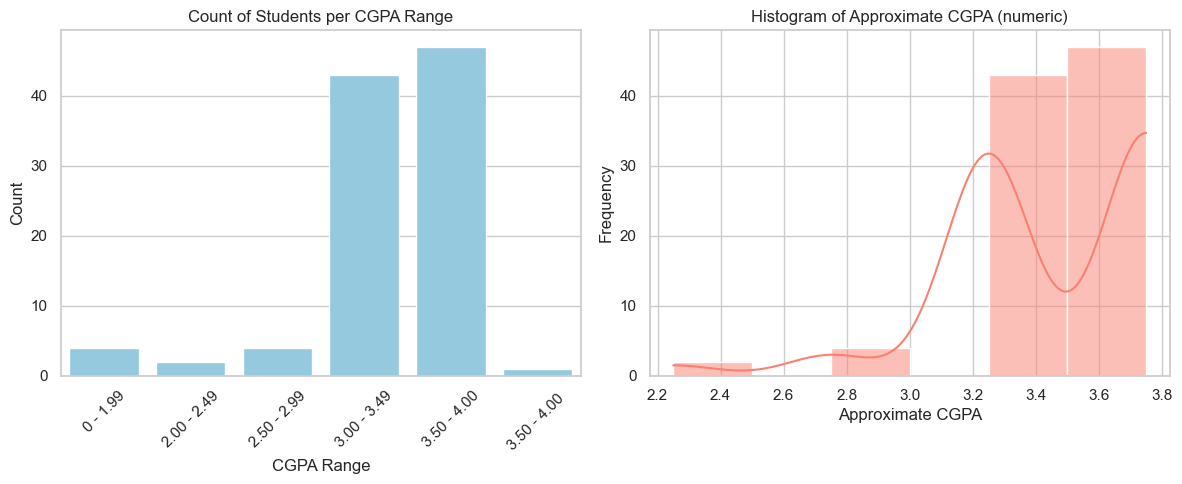

In [29]:
plt.figure(figsize=(12,5))

# Bar plot by category
plt.subplot(1,2,1)
sns.countplot(data=df, x='What is your CGPA?', order=sorted(df['What is your CGPA?'].unique()), color='skyblue')
plt.title("Count of Students per CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Histogram using numeric approx
plt.subplot(1,2,2)
sns.histplot(df['CGPA_numeric'].dropna(), bins=6, kde=True, color='salmon')
plt.title("Histogram of Approximate CGPA (numeric)")
plt.xlabel("Approximate CGPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Exercise 2: Comparing Anxiety Levels Across Different Genders

Create a bar plot comparing the proportion of students reporting anxiety by gender.

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_12793/3423122551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anxiety_by_gender, x='Choose your gender', y='Do you have Anxiety?_num', palette='coolwarm')


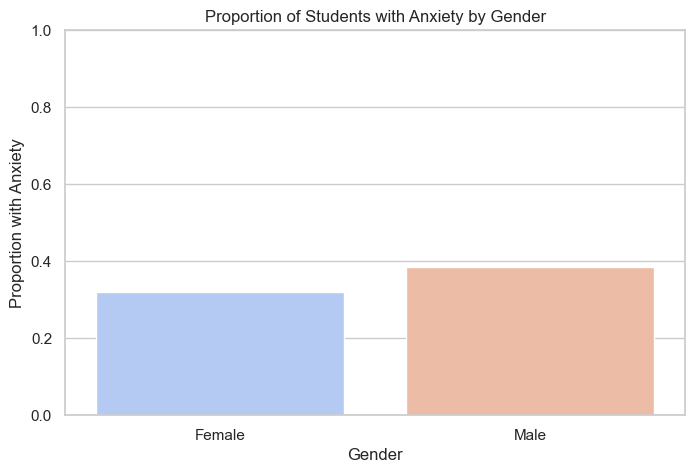

In [30]:
plt.figure(figsize=(8,5))

# We create a bar plot showing proportion with anxiety = 1 per gender
# Calculate proportions manually
anxiety_by_gender = df.groupby('Choose your gender')['Do you have Anxiety?_num'].mean().reset_index()

sns.barplot(data=anxiety_by_gender, x='Choose your gender', y='Do you have Anxiety?_num', palette='coolwarm')

plt.title("Proportion of Students with Anxiety by Gender")
plt.ylabel("Proportion with Anxiety")
plt.xlabel("Gender")
plt.ylim(0,1)

plt.show()

## Exercise 3: Exploring the Relationship Between Age and Panic Attacks

Scatter plot of Age vs Panic attack (binary numeric).

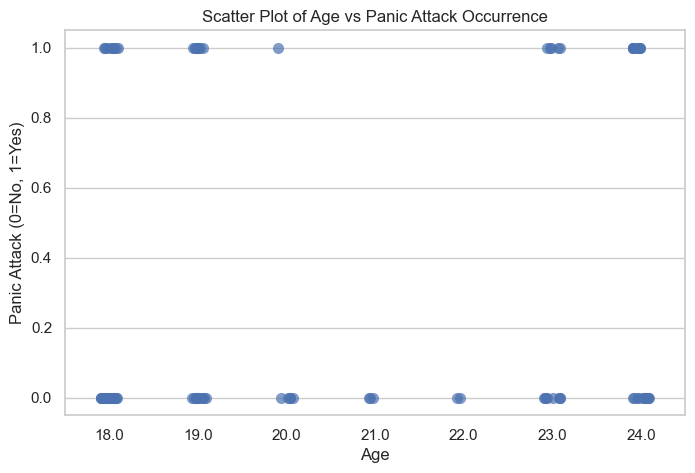

In [31]:
plt.figure(figsize=(8,5))

# Scatter plot with jitter on y axis to separate points since panic attack is binary
sns.stripplot(x='Age', y='Do you have Panic attack?_num', data=df, jitter=0.1, size=8, alpha=0.7)

plt.title("Scatter Plot of Age vs Panic Attack Occurrence")
plt.xlabel("Age")
plt.ylabel("Panic Attack (0=No, 1=Yes)")

plt.show()

## Exercise 4: Visualizing Pairwise Relationships with Seaborn Pair Plot

Pair plot of Age, CGPA_numeric, Depression_num, Anxiety_num, Panic_attack_num with hue on Anxiety.

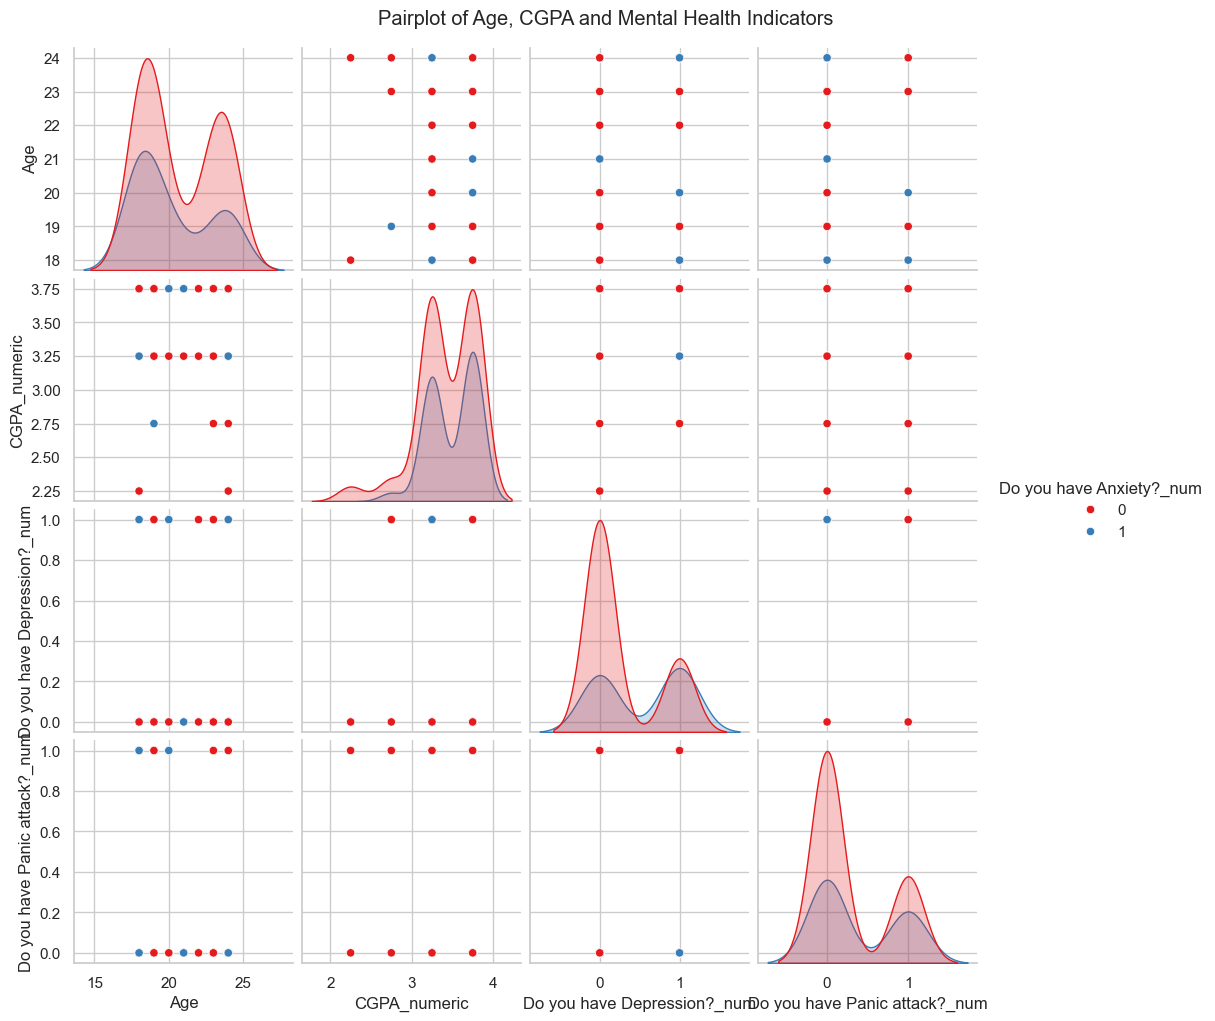

In [32]:
cols = ['Age', 'CGPA_numeric', 'Do you have Depression?_num', 'Do you have Anxiety?_num', 'Do you have Panic attack?_num']

sns.pairplot(df[cols].dropna(), hue='Do you have Anxiety?_num', palette='Set1', diag_kind='kde')
plt.suptitle("Pairplot of Age, CGPA and Mental Health Indicators", y=1.02)
plt.show()


## Exercise 5: Creating a Heatmap to Visualize Correlations

Correlation matrix heatmap of Age, CGPA_numeric, Depression_num, Anxiety_num, Panic_attack_num

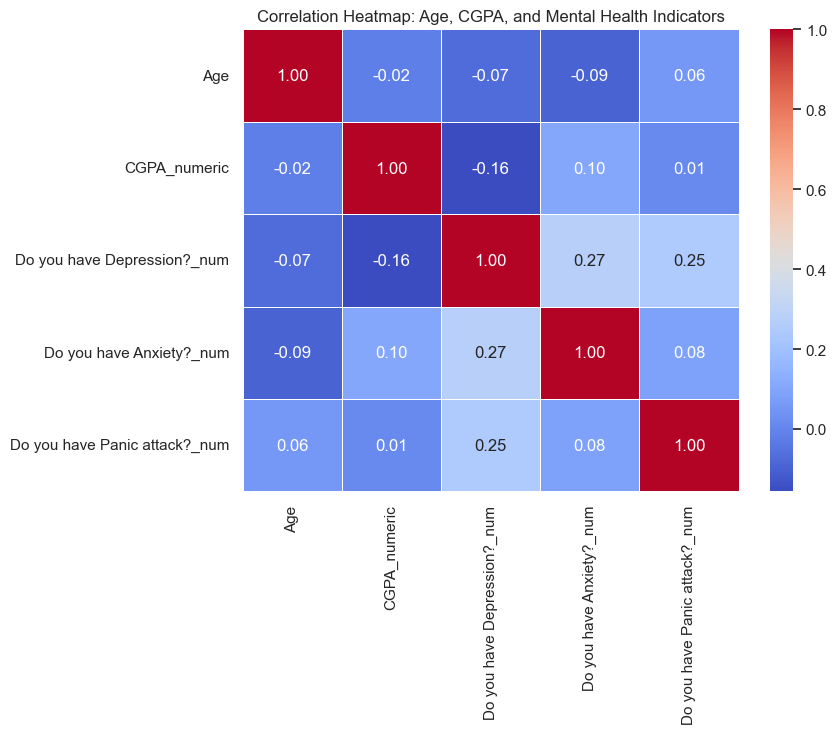

In [33]:
plt.figure(figsize=(8,6))
corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap: Age, CGPA, and Mental Health Indicators")
plt.show()

## Exercise 6: Analyzing Distributions and Relationships Using FacetGrid

Distribution of CGPA_numeric by Depression status.

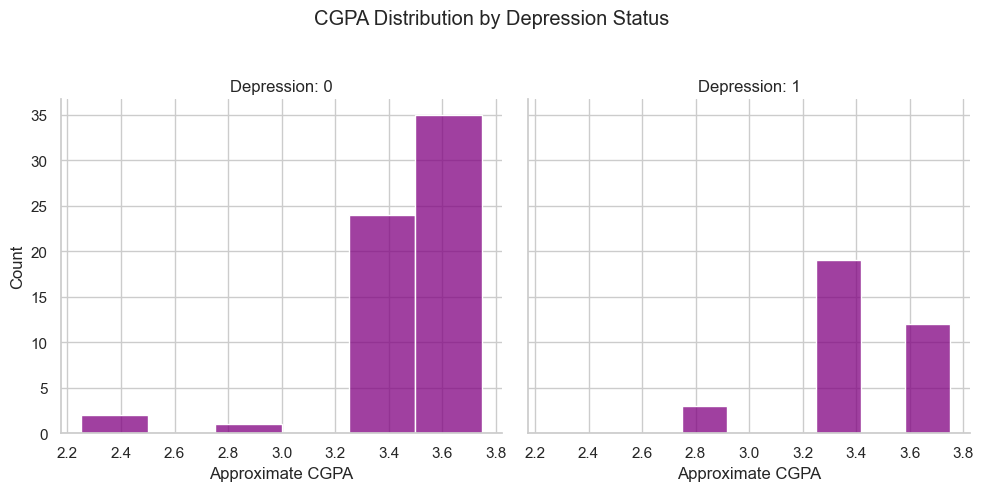

In [34]:
g = sns.FacetGrid(df.dropna(subset=['CGPA_numeric', 'Do you have Depression?_num']), col='Do you have Depression?_num', height=5, aspect=1)
g.map(sns.histplot, 'CGPA_numeric', bins=6, color='purple')
g.set_axis_labels("Approximate CGPA", "Count")
g.set_titles(col_template="Depression: {col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("CGPA Distribution by Depression Status")
plt.show()